# Financial Addiction Detection: Behavioral Clustering and State Machine

This notebook implements:
1. Advanced feature engineering (weekly aggregation)
2. Unsupervised clustering (DBSCAN) and Anomaly Detection (Isolation Forest)
3. A 4-state behavioral escalation machine based on the DSM-5 label anchors and weekly deltas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Data Loading

In [2]:
users = pd.read_csv('../data/users.csv')
sessions = pd.read_csv('../data/sessions.csv', parse_dates=['start_time', 'end_time'])
transactions = pd.read_csv('../data/transactions.csv', parse_dates=['timestamp'])
labels = pd.read_csv('../data/labels.csv')

print(f"Loaded {len(users)} users, {len(sessions)} sessions, {len(transactions)} transactions.")

Loaded 5000 users, 189583 sessions, 2135126 transactions.


## 2. Feature Engineering (Weekly Vectors)
We aggregate behavioral features on a weekly basis for each user.

In [3]:
# Assign year-week to transactions and sessions
transactions['year_week'] = transactions['timestamp'].dt.strftime('%Y-%U')
sessions['year_week'] = sessions['start_time'].dt.strftime('%Y-%U')

# Pre-compute some session properties
sessions['duration_hrs'] = (sessions['end_time'] - sessions['start_time']).dt.total_seconds() / 3600
sessions['prev_end'] = sessions.groupby('user_id')['end_time'].shift(1)
sessions['retry_time_mins'] = (sessions['start_time'] - sessions['prev_end']).dt.total_seconds() / 60
sessions['quick_retry'] = (sessions['retry_time_mins'] <= 15).astype(int)
sessions['late_night'] = sessions['start_time'].dt.hour.between(0, 5).astype(int)

# Pre-compute some transaction properties
tx_sorted = transactions.sort_values(['user_id', 'timestamp'])
tx_sorted['is_bet'] = (tx_sorted['transaction_type'] == 'bet').astype(int)
tx_sorted['is_deposit'] = (tx_sorted['transaction_type'] == 'deposit').astype(int)
tx_sorted['is_weekend'] = tx_sorted['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
tx_sorted['late_night'] = tx_sorted['timestamp'].dt.hour.between(0, 5).astype(int)

# Loss chase calculation
bets = tx_sorted[tx_sorted['is_bet'] == 1].copy()
bets['prev_amount'] = bets.groupby('user_id')['amount'].shift(1)
bets['prev_timestamp'] = bets.groupby('user_id')['timestamp'].shift(1)
bets['prev_session'] = bets.groupby('user_id')['session_id'].shift(1)

chase_mask = (
    (bets['session_id'] == bets['prev_session']) &
    ((bets['timestamp'] - bets['prev_timestamp']).dt.total_seconds() <= 1800) &
    (bets['amount'] > bets['prev_amount'] * 1.5)
)
bets['is_chase'] = chase_mask.astype(int)

tx_features = tx_sorted.merge(bets[['transaction_id', 'is_chase']], on='transaction_id', how='left')
tx_features['is_chase'] = tx_features['is_chase'].fillna(0)

# Weekly Aggregation
weekly_tx = tx_features.groupby(['user_id', 'year_week']).agg(
    txn_frequency=('transaction_id', 'count'),
    night_txns=('late_night', 'sum'),
    weekend_txns=('is_weekend', 'sum'),
    total_bets=('is_bet', 'sum'),
    total_deposits=('is_deposit', 'sum'),
    chase_bets=('is_chase', 'sum'),
    amount_variance=('amount', 'var')
).reset_index()

weekly_sessions = sessions.groupby(['user_id', 'year_week']).agg(
    session_count=('session_id', 'count'),
    quick_retries=('quick_retry', 'sum')
).reset_index()

# Combine
weekly_features = pd.merge(weekly_tx, weekly_sessions, on=['user_id', 'year_week'], how='outer').fillna(0)

# Calculate ratios
weekly_features['night_hour_ratio'] = weekly_features['night_txns'] / (weekly_features['txn_frequency'] + 1e-5)
weekly_features['weekend_skew'] = weekly_features['weekend_txns'] / (weekly_features['txn_frequency'] + 1e-5)
weekly_features['loss_chase_ratio'] = weekly_features['chase_bets'] / (weekly_features['total_bets'] + 1e-5)
weekly_features['session_retry_rate'] = weekly_features['quick_retries'] / (weekly_features['session_count'] + 1e-5)
weekly_features['income_spend_ratio'] = weekly_features['total_deposits'] / (weekly_features['total_bets'] + 1e-5)

# Fill NaN variance with 0
weekly_features['amount_variance'] = weekly_features['amount_variance'].fillna(0)

## 3. Unsupervised ML: DBSCAN & Isolation Forest
We apply clustering and anomaly detection on the aggregated per-user baseline features to find behavioral segments and outliers.

In [4]:
# Aggregate to user level for baseline clustering
user_features = weekly_features.groupby('user_id').agg({
    'txn_frequency': 'mean',
    'night_hour_ratio': 'mean',
    'loss_chase_ratio': 'mean',
    'session_retry_rate': 'mean',
    'income_spend_ratio': 'mean',
    'amount_variance': 'mean',
    'weekend_skew': 'mean'
}).fillna(0)

# Standard Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features)

# DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)
user_features['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Isolation Forest Anomaly Detection
iso_forest = IsolationForest(contamination=0.05, random_state=42)
user_features['anomaly_score'] = iso_forest.fit_predict(X_scaled)  # -1 for anomalies, 1 for normal

print("DBSCAN Clusters Found:", user_features['dbscan_cluster'].nunique())
print("Anomalies Found (Isolation Forest):", (user_features['anomaly_score'] == -1).sum())

DBSCAN Clusters Found: 3
Anomalies Found (Isolation Forest): 250


### Visualizing Clusters

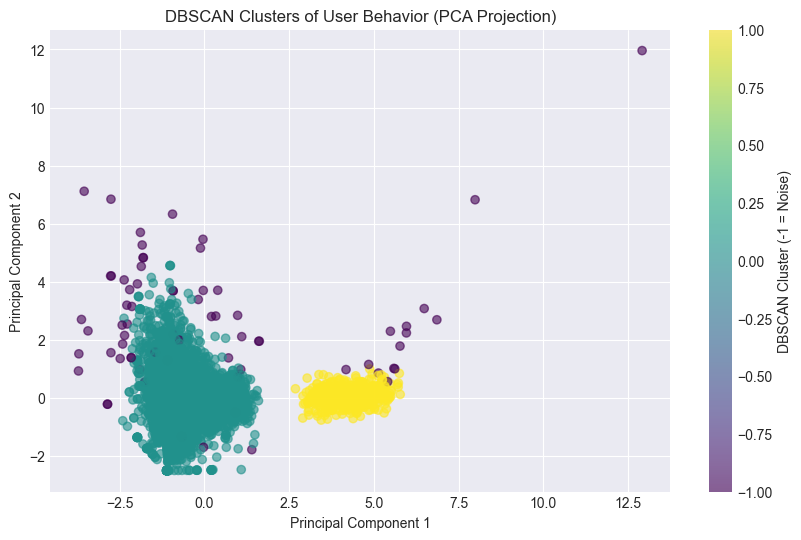

In [5]:
# PCA for 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=user_features['dbscan_cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='DBSCAN Cluster (-1 = Noise)')
plt.title('DBSCAN Clusters of User Behavior (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('../data/dbscan_clusters.png', bbox_inches='tight')
plt.show()

### Visualizing Anomalies

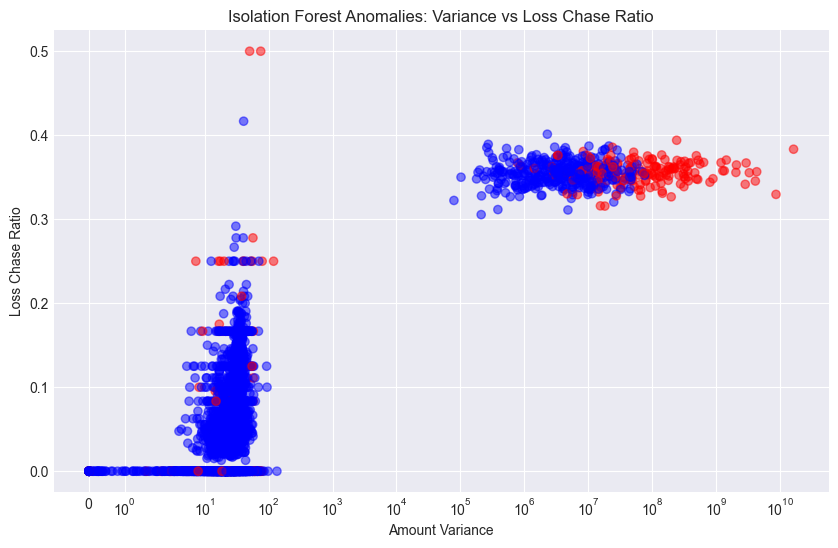

In [6]:
plt.figure(figsize=(10, 6))
# Highlight anomalies
colors = np.where(user_features['anomaly_score'] == -1, 'red', 'blue')
plt.scatter(user_features['amount_variance'], user_features['loss_chase_ratio'], c=colors, alpha=0.5)
plt.title('Isolation Forest Anomalies: Variance vs Loss Chase Ratio')
plt.xlabel('Amount Variance')
plt.ylabel('Loss Chase Ratio')
# Log scale for variance as it can be highly skewed
plt.xscale('symlog')
plt.savefig('../data/anomaly_scatter.png', bbox_inches='tight')
plt.show()

## 4. State Machine Evaluation (Weekly)

**Logic Distinction**:
1. **Primary Anchor (WHAT defines a state)**: The DSM-5 proxy score (0-9).
   - Low (0-2) -> Casual
   - Moderate (3-5) -> Frequent
   - High (6-7) -> Compulsive
   - High (8-9) -> Crisis
2. **Within-Week Transitions (WHEN they move)**: Driven by weekly deltas (e.g. variance spikes). If a user escalates significantly over their baseline, they move up one state. If they de-escalate, they move down.
3. **Override Flag**: Isolation forest anomaly triggers a forced state of `Crisis (Review)`.

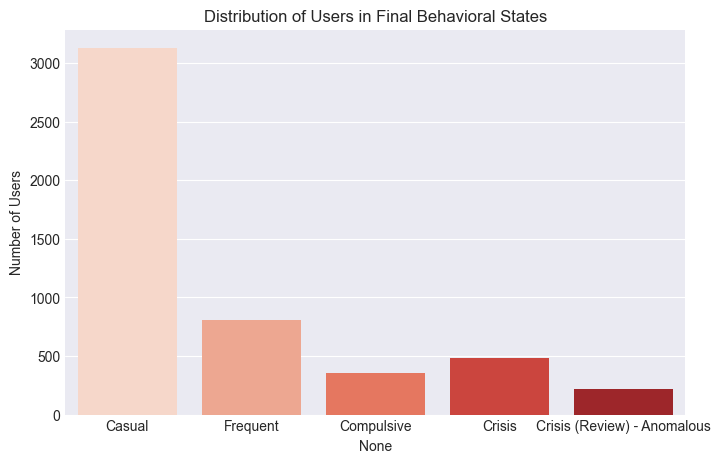

In [7]:
# Map base states from DSM-5 labels
def map_base_state(score):
    if score <= 2: return 0 # Casual
    if score <= 5: return 1 # Frequent
    if score <= 7: return 2 # Compulsive
    return 3 # Crisis

labels['base_state'] = labels['total_score'].apply(map_base_state)
base_state_dict = dict(zip(labels['user_id'], labels['base_state']))

# We'll evaluate the state machine over time for a subset of users or all users.
# For efficiency, let's track the final state of each user at the end of the history.
final_states = {}
state_names = {0: 'Casual', 1: 'Frequent', 2: 'Compulsive', 3: 'Crisis', 4: 'Crisis (Review) - Anomalous'}

# Apply isolation forest to the WEEKLY features to find weekly anomalies
# Fit IF on weekly data
weekly_features_numeric = weekly_features[['txn_frequency', 'night_hour_ratio', 'loss_chase_ratio', 'session_retry_rate', 'income_spend_ratio', 'amount_variance', 'weekend_skew']]
X_weekly_scaled = scaler.fit_transform(weekly_features_numeric)
iso_weekly = IsolationForest(contamination=0.02, random_state=42)
weekly_features['weekly_anomaly'] = iso_weekly.fit_predict(X_weekly_scaled)

# Sort weekly features temporally
weekly_features = weekly_features.sort_values(['user_id', 'year_week'])

for user_id, group in weekly_features.groupby('user_id'):
    current_state = base_state_dict.get(user_id, 0)
    
    # Track historical baselines to compute deltas
    hist_variance = []
    hist_chase = []
    
    for _, row in group.iterrows():
        # Override flag
        if row['weekly_anomaly'] == -1:
            current_state = 4 # Crisis (Review)
            continue
            
        # Delta logic
        if len(hist_variance) > 0:
            avg_var = np.mean(hist_variance)
            avg_chase = np.mean(hist_chase)
            
            # Escalation: Variance spikes > 50% AND chase ratio > baseline
            if avg_var > 0 and row['amount_variance'] > avg_var * 1.5 and row['loss_chase_ratio'] > avg_chase + 0.1:
                current_state = min(3, current_state + 1)
            # De-escalation: Variance drops and chase is 0
            elif avg_var > 0 and row['amount_variance'] < avg_var * 0.5 and row['loss_chase_ratio'] == 0:
                current_state = max(0, current_state - 1)
                
        # Recover from anomaly review state if next week is normal
        if current_state == 4 and row['weekly_anomaly'] != -1:
            current_state = base_state_dict.get(user_id, 0)
                
        hist_variance.append(row['amount_variance'])
        hist_chase.append(row['loss_chase_ratio'])
        
    final_states[user_id] = current_state

# Distribution of final states
final_state_counts = pd.Series(final_states).value_counts().sort_index()
final_state_counts.index = final_state_counts.index.map(state_names)

plt.figure(figsize=(8, 5))
sns.barplot(x=final_state_counts.index, y=final_state_counts.values, palette='Reds')
plt.title('Distribution of Users in Final Behavioral States')
plt.ylabel('Number of Users')
plt.savefig('../data/state_distribution.png', bbox_inches='tight')
plt.show()

### Conclusion
The state machine successfully bridges the static DSM-5 labels with dynamic weekly behavior. Anomalous behavior acts as an instant circuit breaker (forcing a Crisis Review), while week-over-week escalating variance drives internal state promotions.